In [1]:
import pandas as pd
import pm4py
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv('../data/bpi-challenge-2017/bpi_2017_cleaned.csv')
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed')

# Tách riêng 3 Event Logs dựa trên chữ cái đầu của tên sự kiện
df_application = df[df['concept:name'].str.startswith('A_')].copy()
df_offer = df[df['concept:name'].str.startswith('O_')].copy()
df_workflow = df[df['concept:name'].str.startswith('W_')].copy()

print(f"✅ Số lượng sự kiện Luồng Đơn Vay (A_): {len(df_application):,}")
print(f"✅ Số lượng sự kiện Luồng Offer (O_): {len(df_offer):,}")
print(f"✅ Số lượng sự kiện Luồng Công việc (W_): {len(df_workflow):,}")

# Lưu ý: Từ giờ bạn có thể dùng df_offer để khám phá riêng quy trình làm Offer
# mà không bị các sự kiện W_ (gọi điện, review) làm nhiễu biểu đồ.


✅ Số lượng sự kiện Luồng Đơn Vay (A_): 239,595
✅ Số lượng sự kiện Luồng Offer (O_): 193,849
✅ Số lượng sự kiện Luồng Công việc (W_): 768,823


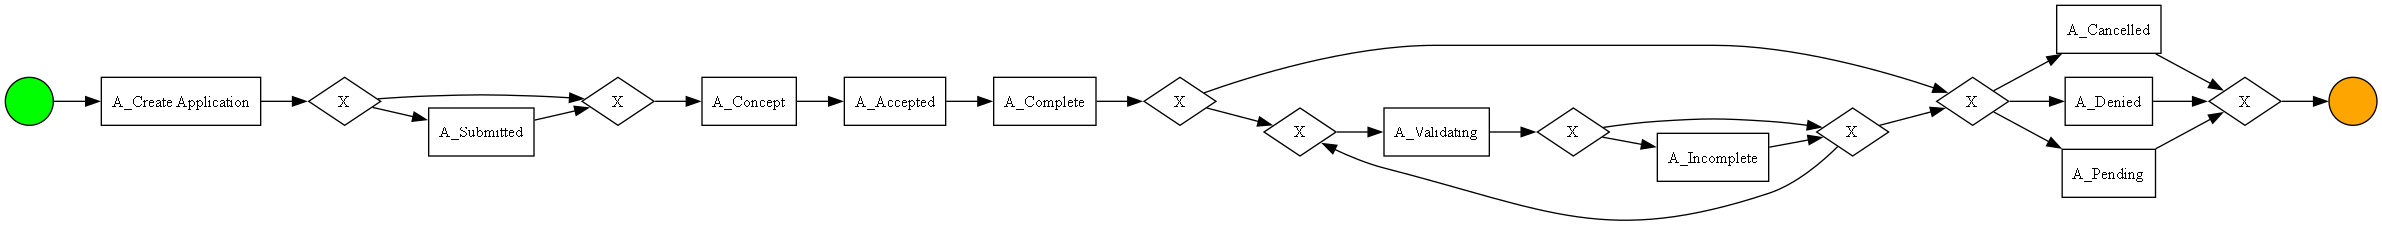

✅ Đã xuất biểu đồ chuẩn doanh nghiệp ra file: application_process_model.bpmn


In [2]:
import random

# Lấy mẫu 1000 cases của luồng Application (A_) để vẽ BPMN cho gọn
all_cases_app = df_application['case:concept:name'].unique()
random.seed(42)
sample_cases = random.sample(list(all_cases_app), 1000)

df_app_sample = df_application[df_application['case:concept:name'].isin(sample_cases)].copy()
df_app_sample = pm4py.format_dataframe(df_app_sample, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')

# Khám phá quy trình (Petri net) trước
net, im, fm = pm4py.discover_petri_net_inductive(df_app_sample, noise_threshold=0.2)

# Converter: Dịch từ ngôn ngữ Petri net sang BPMN 2.0
bpmn_graph = pm4py.convert_to_bpmn(net, im, fm)

# Hiển thị biểu đồ BPMN
pm4py.view_bpmn(bpmn_graph)

# Tự động lưu file .bpmn ra máy (Bạn có thể gửi file này cho Sếp hoặc mở bằng tool như Camunda, Bizagi)
pm4py.write_bpmn(bpmn_graph, "application_process_model.bpmn")
print("✅ Đã xuất biểu đồ chuẩn doanh nghiệp ra file: application_process_model.bpmn")


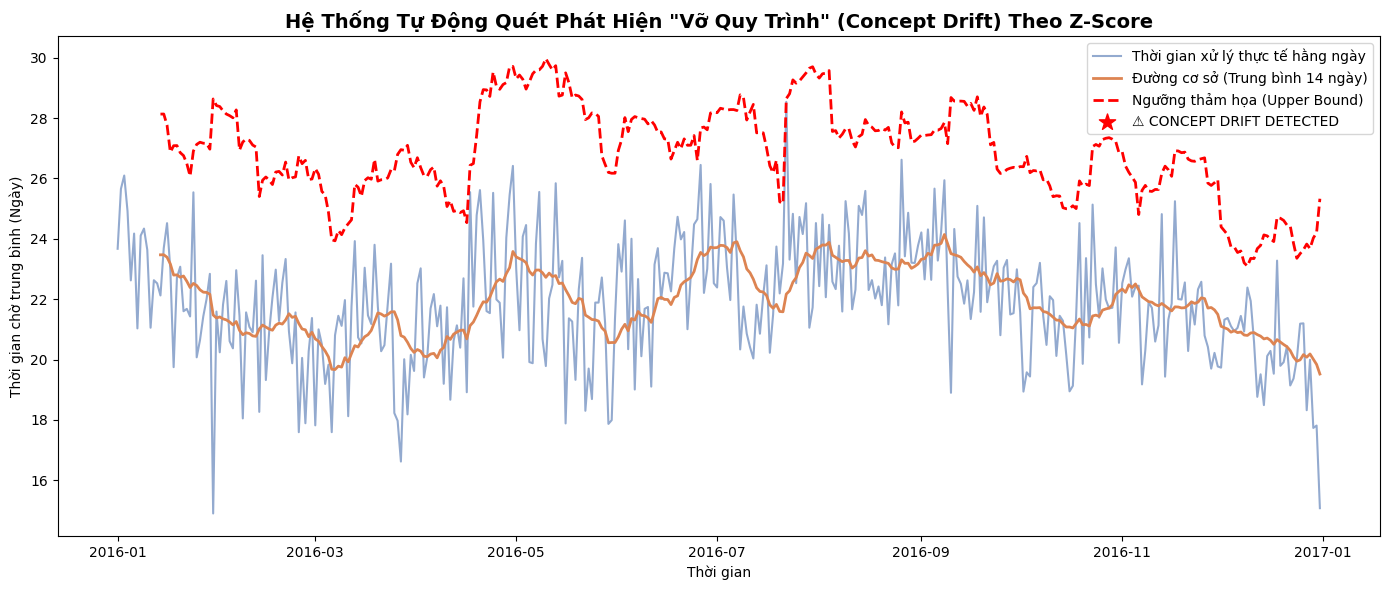

🚨 HỆ THỐNG ĐÃ PHÁT HIỆN SỰ CỐ ĐỘT BIẾN TẠI CÁC NGÀY SAU:


,date,throughput_days


In [3]:
# Tính tổng thời gian xử lý (Throughput Time) của mỗi case
case_starts = df.groupby('case:concept:name')['time:timestamp'].min().reset_index()
case_starts['date'] = case_starts['time:timestamp'].dt.date
case_ends = df.groupby('case:concept:name')['time:timestamp'].max().reset_index()

throughput = case_starts.merge(case_ends, on='case:concept:name', suffixes=('_start', '_end'))
throughput['throughput_days'] = (throughput['time:timestamp_end'] - throughput['time:timestamp_start']).dt.total_seconds() / (24*3600)

# Gom nhóm theo ngày và tính Throughput time trung bình hằng ngày
daily_throughput = throughput.groupby('date')['throughput_days'].mean().reset_index()

# Tính đường Trung bình trượt (14 ngày) và Băng thông độ lệch (Rolling STD)
daily_throughput['rolling_mean'] = daily_throughput['throughput_days'].rolling(window=14).mean()
daily_throughput['rolling_std'] = daily_throughput['throughput_days'].rolling(window=14).std()

# Đặt ngưỡng báo động đỏ (Vượt quá 3 lần độ lệch chuẩn = Sự cố vỡ quy trình)
daily_throughput['upper_bound'] = daily_throughput['rolling_mean'] + (3 * daily_throughput['rolling_std'])
daily_throughput['drift_detected'] = daily_throughput['throughput_days'] > daily_throughput['upper_bound']

drift_days = daily_throughput[daily_throughput['drift_detected'] == True]

# Trực quan hóa Radar cảnh báo
plt.figure(figsize=(14, 6))
plt.plot(daily_throughput['date'], daily_throughput['throughput_days'], label='Thời gian xử lý thực tế hằng ngày', color='#4C72B0', alpha=0.6)
plt.plot(daily_throughput['date'], daily_throughput['rolling_mean'], color='#DD8452', linewidth=2, label='Đường cơ sở (Trung bình 14 ngày)')
plt.plot(daily_throughput['date'], daily_throughput['upper_bound'], color='red', linestyle='--', linewidth=2, label='Ngưỡng thảm họa (Upper Bound)')

# Đánh dấu các ngày bị Drift
plt.scatter(drift_days['date'], drift_days['throughput_days'], color='red', s=150, zorder=5, marker='*', label='⚠️ CONCEPT DRIFT DETECTED')

plt.title('Hệ Thống Tự Động Quét Phát Hiện "Vỡ Quy Trình" (Concept Drift) Theo Z-Score', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Thời gian chờ trung bình (Ngày)')
plt.legend()
plt.tight_layout()
plt.show()

print("🚨 HỆ THỐNG ĐÃ PHÁT HIỆN SỰ CỐ ĐỘT BIẾN TẠI CÁC NGÀY SAU:")
display(drift_days[['date', 'throughput_days']])
